# Structural and Geolocation Anomaly Analysis, Raw AROME Station Extract

This notebook documents a first-pass inspection of the raw AROME point-extraction file (`data/raw/Arome`), preceding any cleaning or merge step with the METAR archive. The file carries no header and no accompanying schema documentation, so the analysis begins from direct inspection of the raw text rather than from an assumed column layout.

The objective is diagnostic rather than corrective: to establish which structural and geolocation inconsistencies exist in the raw extract, whether they are isolated occurrences or systematic, and what evidence supports each hypothesis. The resulting findings inform the filtering and deduplication logic implemented downstream.


In [2]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

## 1. Raw Format Inspection

The first ten lines are read without any parsing to establish the field layout, delimiter pattern, and general regularity of the file before any assumptions are encoded in code.


In [3]:
with open("../data/raw/Arome", "r", encoding="utf-8") as f:
    for i in range(10):
        print(repr(f.readline()))

' 60033 2021010100\t  -13.2000   27.1500 -.3756980896     -2.860277176      286.7445374     0.7582868189     -.5298585892     -11.77752876     -2.984561920     -9.461303711      101380.1250     -.3789710999     -2.863943100     0.1000000000E-05 0.1000000000E-05  10.00000000    \n'
' 60060 2021010100\t  -10.1750   29.3500 -1.258510590      2.202222824      285.1419983     0.9716657251     0.8451414108     -7.957216263     0.7341880798     -3.945678711      98982.12500     -1.261783600      2.206369400     0.1000000000E-05 0.1000000000E-05  10.00000000    \n'
' 60096 2021010100\t  -15.8500   23.7000 -3.117885590     -5.829027176      290.8373108     0.8491071314     -1.998608589     -5.933778763     -7.156436920     -8.117553711      101979.1250     -3.121158600     -5.832693100     0.1000000000E-05 0.1000000000E-05  10.00000000    \n'
' 60101 2021010100\t   -5.9000   35.7250  1.171176910      7.928785324      281.7953186     0.7907575220      16.14201641     -2.824403763      12.4060630

Each line is tokenised on whitespace and loaded into a DataFrame without column names or type coercion. This unassuming pass serves as a baseline: it exposes whether `str.split()` returns a consistent token count across rows before any schema is imposed on the data.


In [4]:
import pandas as pd

rows = []

with open("../data/raw/Arome", "r") as f:
    for line in f:
        rows.append(line.split())

df = pd.DataFrame(rows)

print(df.head())
print(df.shape)

      0           1         2        3             4             5   \
0  60033  2021010100  -13.2000  27.1500  -.3756980896  -2.860277176   
1  60060  2021010100  -10.1750  29.3500  -1.258510590   2.202222824   
2  60096  2021010100  -15.8500  23.7000  -3.117885590  -5.829027176   
3  60101  2021010100   -5.9000  35.7250   1.171176910   7.928785324   
4  60107  2021010100   -3.8500  35.1750  0.5930519104   2.686597824   

            6             7             8             9             10  \
0  286.7445374  0.7582868189  -.5298585892  -11.77752876  -2.984561920   
1  285.1419983  0.9716657251  0.8451414108  -7.957216263  0.7341880798   
2  290.8373108  0.8491071314  -1.998608589  -5.933778763  -7.156436920   
3  281.7953186  0.7907575220   16.14201641  -2.824403763   12.40606308   
4  281.7103577  0.5119489282   12.25139141  -4.465028763   6.859188080   

             11           12            13            14                15  \
0  -9.461303711  101380.1250  -.3789710999  -2.863

### Column Mappingm AROME FullPos Extraction Namelist

The variable ordering is resolved directly from the FullPos extraction namelist (`NAML`) used to produce the point extraction, via the `TABCH` array, which fixes the field order unambiguously:

| Position | `TABCH` entry | Field | Description |
|---|---|---|---|
| 5 | `TABCH(1)` = `CLSVENT.ZONAL` | `u10` | 10 m zonal wind component |
| 6 | `TABCH(2)` = `CLSVENT.MERIDIEN` | `v10` | 10 m meridional wind component |
| 7 | `TABCH(3)` = `CLSTEMPERATURE` | `t2m` | 2 m temperature |
| 8 | `TABCH(4)` = `CLSHUMI.RELATIVE` | `rh2m` | 2 m relative humidity |
| 9 | `TABCH(5)` = `P85000VENT_ZONAL` | `u850` | Zonal wind at 850 hPa |
| 10 | `TABCH(6)` = `P85000VENT_MERID` | `v850` | Meridional wind at 850 hPa |
| 11 | `TABCH(7)` = `P95000VENT_ZONAL` | `u950` | Zonal wind at 950 hPa |
| 12 | `TABCH(8)` = `P95000VENT_MERID` | `v950` | Meridional wind at 950 hPa |
| 13 | `TABCH(9)` = `SURFPRESSION` | `psurf` | Surface pressure |
| 14 | `TABCH(10)` = `CLSU.RAF60M.XFU` | `u_gust60` | 10 m zonal gust, 60-minute maximum |
| 15 | `TABCH(11)` = `CLSV.RAF60M.XFU` | `v_gust60` | 10 m meridional gust, 60-minute maximum |
| 16 | `TABCH(12)` = `H00020TKE` | `tke20m` | Turbulent kinetic energy at 20 m |
| 17 | `TABCH(13)` = `H00020EDR` | `edr20m` | Eddy dissipation rate at 20 m |
| 18 | `TABCH(14)` = `CLPMHAUT.MOD.XFU` | `pblh` | Boundary-layer height |


In [5]:
df.columns = [
    "station", "datetime", "lon", "lat",
    "u10", "v10", "t2m", "rh2m",
    "u850", "v850", "u950", "v950",
    "psurf", "u_gust60", "v_gust60",
    "tke20m", "edr20m", "pblh"
]


## 2. Anomaly 1 — Malformed Station Identifiers

The `station` field is expected to hold a 5-digit WMO synoptic code in all rows. Rows where this field fails to match `\d+` are isolated to quantify the extent of the issue and to inspect the actual content of the offending values.


In [6]:
bad = df[~df["station"].str.fullmatch(r"\d+")]

print(len(bad))
print(bad.head(10))

133
        station datetime           lon           lat          u10  \
2112    -6.6000  34.3000  -.8351325989  -.2778348923  277.2294922   
2725    -5.9000  35.7250  -2.748641968  -2.185529709  282.6208496   
4356    -6.0500  34.2250  -1.609692574  -1.668593407  289.3071289   
5816   -10.0500  29.0000  -.5776185989   1.559943199  290.3203125   
6043    -7.5750  33.3500  0.2278757095  -.2459259033  283.6538086   
7512   -17.5000  31.9250  -3.796563148  -.7108945847  291.8176270   
7536   -11.1500  28.4500  -1.473565102   1.265403748  288.3581543   
7751    -4.4000  31.9250   1.291069031  -.2631788254  274.6447754   
9654    -5.5250  33.8750  -.1412000656   1.205712318  281.2668457   
10279   -7.6500  33.5500  0.4661350250   3.715668678  281.8767090   

                v10           t2m              rh2m          u850  \
2112   0.9627947360   2.840205193      -.9920024872  -.1984863281   
2725   0.9615488648  -3.691471100      -1.815706253  -2.400039673   
4356   0.5173039436  -6.16723

Row index 2112, previously flagged during manual inspection, is retrieved in both raw and tokenised form to determine whether the anomaly originates from the parsing step or is already present in the source line.


In [7]:
idx = 2112

with open("../data/raw/Arome", "r") as f:
    for i, line in enumerate(f):
        if i == idx:
            print(repr(line))
            print(line.split())
            print(len(line.split()))
            break

'\t   -6.6000   34.3000 -.8351325989     -.2778348923      277.2294922     0.9627947360      2.840205193     -.9920024872     -.1984863281     -.6799249649      102706.4141     -1.063873291      1.847749710     0.9999994290E-06 0.9999994290E-06  9.999999046    \n'
['-6.6000', '34.3000', '-.8351325989', '-.2778348923', '277.2294922', '0.9627947360', '2.840205193', '-.9920024872', '-.1984863281', '-.6799249649', '102706.4141', '-1.063873291', '1.847749710', '0.9999994290E-06', '0.9999994290E-06', '9.999999046']
16


A subset of the malformed `station` values begins with the prefix `20`, matching the leading digits of the `datetime` field (`20YYMMDDHH`) rather than any valid WMO code in the `60xxx` range used throughout this dataset. Rows exhibiting this pattern are extracted to test the hypothesis that the date field has been displaced into the station column.


In [8]:
date_rows = df[df["station"].str.startswith("20")]

print("Nombre de lignes :", len(date_rows))
print(date_rows.head())

Nombre de lignes : 6244
        station datetime      lon           lat           u10          v10  \
53   2021010102  -7.6500  33.5500  0.1583528519   3.731693268  277.9846039   
73   2021010102  -1.9250  34.7750  0.7858877182  0.8394956589  279.8942871   
157  2021010106  -9.5500  20.5000  -.8879041672  -3.929071426  286.7074280   
193  2021010107  -4.4000  31.9250   1.824395180   1.608144760  276.6621094   
304  2021010111  -3.8500  35.1750  0.5869016647   2.176967621  278.7878418   

              t2m          rh2m              u850          v850          u950  \
53   0.9594272971  0.9918184280      -5.168306351   1.653732300  -2.550811768   
73   0.9994438440  -1.336438179  -.4060649872E-01  -1.776245117  -.3868961334   
157  0.5494880676   9.127240181      -1.366958618  -2.342862129  -10.67016602   
193  0.3867470622   1.255564690      -2.308320999   1.870727539   1.794719696   
304  0.6449671648   2.163220406      -2.237627029   4.722015381  -.1126451492   

            v950    

## 3. Anomaly 2 — Missing Field / Column Shift

The displacement observed above is consistent with a subset of rows missing one field outright, which would shift every subsequent value one position to the left, produce a 17-token row instead of 18, and account for the malformed station values already identified. The file is re-read with per-line token counts to locate the first occurrence of a 17-token row, printed alongside the immediately preceding row for comparison.


In [9]:
with open("../data/raw/Arome") as f:
    lines = [l.split() for l in f]

for i in range(1, len(lines)):
    if len(lines[i]) == 17:
        print("Preceding :", lines[i-1][:4])
        print("Current   :", lines[i][:4])
        print()
        break

Preceding : ['60033', '2021010102', '-7.6500', '33.5500']
Current   : ['2021010102', '-7.6500', '33.5500', '0.1583528519']



If the missing-field hypothesis holds, a 17-token row should be reproducible by dropping the station identifier from the preceding 18-token row. Occurrences of an exact match (`count_same`) versus a mismatch (`count_diff`) are tallied across the full file to determine whether a single mechanism accounts for the anomaly or several distinct failure modes are involved.


In [10]:
with open("../data/raw/Arome") as f:
    lines = [line.split() for line in f]

count_same = 0
count_diff = 0

for i in range(1, len(lines)):
    if len(lines[i]) == 17 and len(lines[i-1]) == 18:
        if lines[i-1][1:] == lines[i]:
            count_same += 1
        else:
            count_diff += 1

print("Copies :", count_same)
print("Different :", count_diff)

Copies : 3268
Different : 2861


An instance where the 17-token row does not reduce to its predecessor is retrieved for inspection. These divergent cases are the more consequential ones, since the exact-match cases are both explainable and recoverable, the missing identifier can be inferred from the row above, whereas divergent cases require separate handling.


In [11]:
with open("../data/raw/Arome") as f:
    lines = [line.split() for line in f]

for i in range(1, len(lines)):
    if len(lines[i]) == 17 and len(lines[i-1]) == 18:
        if lines[i-1][1:] != lines[i]:
            print("Ligne précédente :", lines[i-1])
            print("Ligne actuelle   :", lines[i])
            print()
            break

Ligne précédente : ['60033', '2021010106', '-8.0250', '31.6000', '-.8321666718E-01', '1.547491074', '275.4320374', '0.9847908020', '0.6897401810', '-2.460708618', '-1.858487129', '-.7639160156', '96399.89062', '-.1030988693', '1.846267700', '0.7081078124E-02', '0.1383291010E-03', '9.999999046']
Ligne actuelle   : ['2021010106', '-9.5500', '20.5000', '-.8879041672', '-3.929071426', '286.7074280', '0.5494880676', '9.127240181', '-1.366958618', '-2.342862129', '-10.67016602', '96971.89062', '-1.274973869', '-5.653732300', '0.2153330312', '0.3678368163E-02', '249.8749990']



## 4. Full-File Quantification

Per-row token counts are tabulated across the entire file and grouped into three buckets (18 / 17 / 16 tokens) to move from anecdotal cases to file-wide figures. The 16-token bucket is included specifically to rule out a more severe form of field loss beyond the single missing column already identified.


In [12]:
full18 = []
full17 = []
full16 = []

with open("../data/raw/Arome") as f:
    for line in f:
        values = line.split()

        if len(values) == 18:
            full18.append(values)
        elif len(values) == 17:
            full17.append(values)
        elif len(values) == 16:
            full16.append(values)

print(len(full18), len(full17), len(full16))

1133724 6244 133


Subsequent analysis is restricted to well-formed rows (18 tokens), isolating the coordinate checks below from contamination by the shifted rows, which are addressed separately once a reconstruction-versus-discard decision is made.


In [13]:
df18 = pd.DataFrame(full18, columns=[
    "station", "datetime", "lon", "lat",
    "u10", "v10", "t2m", "q2m",
    "var8", "var9", "var10",
    "pressure",
    "u_gust", "v_gust",
    "var14", "var15",
    "forecast_hour", "var17"
])

## 5. Anomaly 3 — Coordinate Instability per Station

A distinct question is examined here: whether each `(lon, lat)` pair maps to exactly one station identifier, or whether multiple station identifiers share a coordinate. Rows are grouped by coordinate and the count of distinct stations per group is sorted in descending order, providing an initial signal of mislabelled or duplicated grid points.


In [14]:
df18.groupby(["lon", "lat"])["station"].nunique().sort_values(ascending=False).head()

lon       lat    
-9.7750   31.5000    26
-1.9250   34.7750    26
-10.0500  20.5000    26
-1.9500   20.5000    26
-6.6000   20.5000    26
Name: station, dtype: int64

The full inventory of distinct station identifiers present in the well-formed subset is extracted, both to cross-check the count against the 26 synoptic stations expected in this domain and to serve as a reference list for the per-station checks that follow.


In [15]:
print(df18["station"].unique()[:40])
print("Nombre de stations uniques :", df18["station"].nunique())

<StringArray>
['60033', '60060', '60096', '60101', '60107', '60115', '60120', '60135',
 '60136', '60141', '60150', '60155', '60156', '60160', '60191', '60200',
 '60210', '60220', '60230', '60250', '60252', '60265', '60280', '60285',
 '60338', '60340']
Length: 26, dtype: str
Nombre de stations uniques : 26


Station `60033` is examined in isolation: every distinct `(lon, lat)` pair recorded under this identifier is retrieved. A fixed synoptic station should report a single, unchanging coordinate; more than one distinct pair here would constitute direct confirmation of coordinate drift rather than a suspected artefact.


In [16]:
print(df18[df18["station"] == "60033"][["lon", "lat"]].drop_duplicates())

             lon      lat
0       -13.2000  27.1500
52       -7.6500  33.5500
137      -4.9750  33.9250
154      -8.0250  31.6000
204      -4.4000  31.9250
...          ...      ...
192010   -1.9500  35.1750
204356  -13.2000  29.0000
218044   -6.6000  27.1500
460775   -6.0500  27.1500
550285   -2.9500  27.1500

[126 rows x 2 columns]


`lat` and `lon` are cast to numeric type — both fields remain string-typed from the initial whitespace split — and rows failing conversion are dropped, enabling the quantitative and geospatial comparisons that follow.


In [17]:
df["lat"] = pd.to_numeric(df["lat"], errors="coerce")
df["lon"] = pd.to_numeric(df["lon"], errors="coerce")
df = df.dropna(subset=["lat", "lon"])

Every recorded location for station `60033` is plotted on a Folium map, with marker size or count reflecting occurrence frequency. The purpose of the visualisation is to distinguish two qualitatively different scenarios: minor jitter clustered around a single true site, versus coordinates corresponding to an entirely different location — a distinction with direct bearing on the choice of distance threshold applied downstream.


In [ ]:
import pandas as pd
import folium


station_id = "60033"

station = df[df["station"] == station_id].copy()

locations = (
    station
    .groupby(["lat", "lon"])
    .size()
    .reset_index(name="count")
)

center_lat = locations["lat"].mean()
center_lon = locations["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8
)


for _, row in locations.iterrows():

    folium.CircleMarker(
        location=[
            row["lat"],
            row["lon"]
        ],
        radius=max(5, min(row["count"] / 10, 20)),  
        popup=f"""
        Station: {station_id}<br>
        Nombre de mesures: {row['count']}<br>
        Lat: {row['lat']}<br>
        Lon: {row['lon']}
        """,
        color="red",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)


m.save("../outputs/figures/station_density.html")

The same visualisation is repeated for station `60340`, selected because it had already surfaced as a borderline case in earlier lon/lat matching against ICAO station coordinates near Nador. The comparison establishes whether the coordinate-drift pattern observed for `60033` is an isolated occurrence or recurs across stations.


In [ ]:
import pandas as pd
import folium


station_id = "60340"

station = df[df["station"] == station_id].copy()

locations = (
    station
    .groupby(["lat", "lon"])
    .size()
    .reset_index(name="count")
)


center_lat = locations["lat"].mean()
center_lon = locations["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8
)


for _, row in locations.iterrows():

    folium.CircleMarker(
        location=[
            row["lat"],
            row["lon"]
        ],
        radius=max(5, min(row["count"] / 10, 25)),
        popup=f"""
        Station: {station_id}<br>
        Nombre de points: {row['count']}<br>
        Latitude: {row['lat']}<br>
        Longitude: {row['lon']}
        """,
        color="red",
        fill=True,
        fill_opacity=0.6
    ).add_to(m)


    folium.Marker(
        location=[
            row["lat"],
            row["lon"]
        ],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:14px;
                color:black;
                font-weight:bold;
                text-align:center;">
                {row['count']}
            </div>
            """
        )
    ).add_to(m)


m.save("../outputs/figures/station_count_map.html")

print(locations)

        lat     lon  count
0    20.500 -17.500      9
1    20.500 -15.850      7
2    20.500 -13.200      5
3    20.500 -11.150      6
4    20.500 -10.175     30
..      ...     ...    ...
108  35.175  -2.900      2
109  35.275  -2.950     59
110  35.725 -17.500      1
111  35.725  -5.900     26
112  35.725  -2.900      2

[113 rows x 3 columns]


## Summary of Findings

Three distinct anomaly classes are confirmed in the raw AROME extract:

1. **Field shift / column loss** — a subset of rows is missing one field, most frequently the station identifier, shifting all subsequent values left by one position.
2. **Corrupted station identifiers** — a subset of station values correspond to fragments of the date field rather than valid WMO codes, consistent with the field-shift mechanism above.
3. **Coordinate drift** — valid station identifiers are in places associated with coordinates inconsistent with their known fixed location, ranging from small offsets to displacements corresponding to an entirely different site.

These findings motivate a cleaning procedure combining structural validation, a per-station reference coordinate derived from the modal position, a distance threshold to separate acceptable drift from genuine mislabelling, and deduplication on `(station, datetime)`. That procedure is implemented in `src/cleaning`.


# Cleaned Dataset Overview

The analyses presented in the previous sections highlighted several data quality issues in the original AROME dataset, including malformed records, inconsistent station locations, and duplicate observations. These issues must be addressed before the data can be reliably used for machine learning.

To automate this process, a complete cleaning pipeline was implemented in `scripts/cleaning.py`. Rather than performing a single transformation, this script orchestrates four independent cleaning modules located in `src/cleaning/`:

1. **`validate_structure.py`** — validates the structure of every record, removes malformed observations, and standardizes the dataset format.
2. **`compute_reference_coordinates.py`** — computes a reference geographic location for each weather station from the original observations.
3. **`filter_by_distance.py`** — removes observations whose coordinates are farther than a predefined distance threshold from the corresponding station reference location.
4. **`deduplicate.py`** — removes duplicate observations while preserving a single record for each `(station, datetime)` pair.

The execution of this pipeline produces the final cleaned dataset:

```text
data/cleaned/Arome_clean_final.csv
```

A complete execution log of the cleaning pipeline, including intermediate reports and statistics for every step, is available in:

```text
outputs/scripts/cleaning.txt
```

The following table summarizes the outcome of each stage of the cleaning process.

## Objectives of the Exploration

The purpose of this exploratory analysis is not to rediscover the characteristics of the raw dataset, but to validate the effectiveness of the cleaning pipeline.

The following analyses focus on verifying that the major issues identified during the initial exploration have been successfully resolved. In particular, we investigate:

- the overall integrity of the cleaned dataset,
- the removal of duplicate observations,
- the consistency of station identifiers,
- the spatial coherence of station coordinates,
- and the final geographic distribution of the weather stations.

Together, these checks provide confidence that the cleaned dataset is suitable for the preprocessing stage and the construction of machine learning training samples.

In [35]:
import pandas as pd

df = pd.read_csv("../data/cleaned/Arome_clean_final.csv")

station_id = "60033"

station = df[df["id"].astype(str) == station_id]

print(f"Number of rows : {len(station)}")

print("\nNumber of different positions :")
print(
    station[["lat", "lon"]]
    .drop_duplicates()
)

Number of rows : 37940

Number of different positions :
     lat   lon
0  27.15 -13.2


In [36]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows : {duplicates}")

Duplicate rows : 0


In [37]:
import pandas as pd
import folium

# Read the cleaned data
df = pd.read_csv("../data/cleaned/Arome_clean_final.csv")

# One unique position per station
stations = (
    df.groupby("id")[["lat", "lon"]]
      .first()
      .reset_index()
)

# Center of the map
center_lat = stations["lat"].mean()
center_lon = stations["lon"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=6
)

# Add the stations
for _, row in stations.iterrows():

    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color="red",
        fill=True,
        fill_opacity=0.8,
        popup=f"""
        Station : {row['id']}<br>
        Latitude : {row['lat']}<br>
        Longitude : {row['lon']}
        """
    ).add_to(m)

    # Add station name as a label
    folium.Marker(
        location=[row["lat"], row["lon"]],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size:12px;
                font-weight:bold;
                color:black;
                white-space: nowrap;">
                {row['id']}
            </div>
            """
        )
    ).add_to(m)

m.save("../outputs/figures/all_stations_map.html")

print(f"Nombre de stations : {len(stations)}")
print(stations.sort_values("id"))

Nombre de stations : 26
       id     lat     lon
0   60033  27.150 -13.200
1   60060  29.350 -10.175
2   60096  23.700 -15.850
3   60101  35.725  -5.900
4   60107  35.175  -3.850
5   60115  34.775  -1.925
6   60120  34.300  -6.600
7   60135  34.050  -6.750
8   60136  34.225  -6.050
9   60141  33.925  -4.975
10  60150  33.875  -5.525
11  60155  33.550  -7.650
12  60156  33.350  -7.575
13  60160  33.500  -5.150
14  60191  32.350  -6.400
15  60200  32.550  -1.950
16  60210  31.925  -4.400
17  60220  31.500  -9.775
18  60230  31.600  -8.025
19  60250  30.375  -9.550
20  60252  30.325  -9.400
21  60265  30.925  -6.900
22  60280  29.000 -10.050
23  60285  28.450 -11.150
24  60338  35.275  -2.950
25  60340  35.150  -2.900


In [38]:
import pandas as pd

# Load cleaned dataset
df = pd.read_csv("../data/cleaned/Arome_clean_final.csv")

# Count unique coordinate pairs for each station
coordinate_counts = (
    df.groupby("id")
      .apply(lambda x: x[["lat", "lon"]].drop_duplicates().shape[0])
      .reset_index(name="unique_locations")
)

# Keep only stations with more than one coordinate pair
multiple_locations = coordinate_counts[
    coordinate_counts["unique_locations"] > 1
]

if multiple_locations.empty:
    print("Every station is associated with a single coordinate pair.")
else:
    print("Stations associated with multiple coordinate pairs:\n")
    print(multiple_locations)

    print("\nRemaining coordinates after cleaning:\n")

    for station in multiple_locations["id"]:
        print(f"Station {station}")
        print(
            df[df["id"] == station][["lat", "lon"]]
            .drop_duplicates()
            .sort_values(["lat", "lon"])
            .to_string(index=False)
        )
        print("-" * 50)

print(f"\nTotal stations: {coordinate_counts.shape[0]}")
print(f"Stations with multiple coordinate pairs: {multiple_locations.shape[0]}")

Stations associated with multiple coordinate pairs:

       id  unique_locations
5   60115                 2
6   60120                 2
8   60136                 2
9   60141                 2
11  60155                 2
12  60156                 2
15  60200                 2
19  60250                 2
24  60338                 2
25  60340                 4

Remaining coordinates after cleaning:

Station 60115
   lat    lon
34.775 -1.950
34.775 -1.925
--------------------------------------------------
Station 60120
   lat  lon
34.225 -6.6
34.300 -6.6
--------------------------------------------------
Station 60136
   lat   lon
34.225 -6.05
34.300 -6.05
--------------------------------------------------
Station 60141
   lat    lon
33.875 -4.975
33.925 -4.975
--------------------------------------------------
Station 60155
  lat    lon
33.55 -7.650
33.55 -7.575
--------------------------------------------------
Station 60156
  lat    lon
33.35 -7.650
33.35 -7.575
-----------------------

In [39]:
station_counts = (
    df["id"]
      .value_counts()
      .sort_index()
      .rename("Observations")
)

station_counts

id
60033    37940
60060    37714
60096    41503
60101    42043
60107    42048
60115    42091
60120    42101
60135    41992
60136    41941
60141    41942
60150    41852
60155    41918
60156    41903
60160    41978
60191    41988
60200    42007
60210    41952
60220    41933
60230    41887
60250    41949
60252    42074
60265    42056
60280    41964
60285    42065
60338    42121
60340    41925
Name: Observations, dtype: int64

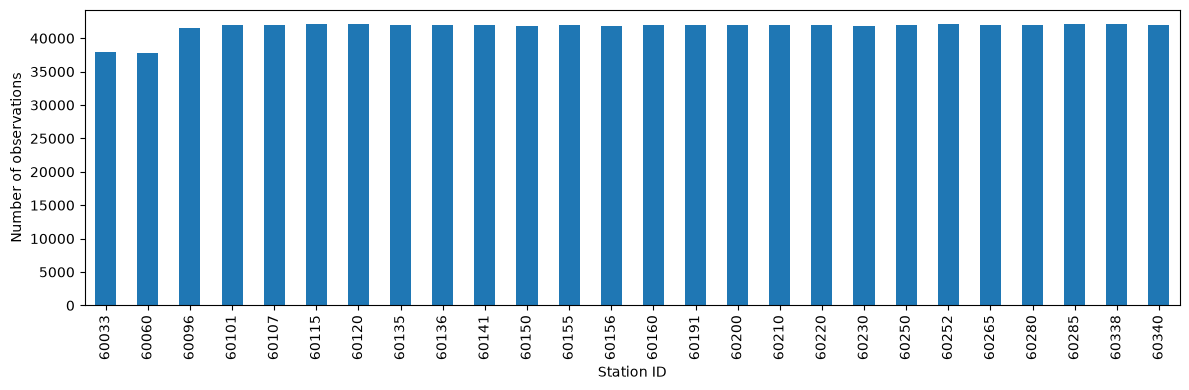

In [40]:
import matplotlib.pyplot as plt

station_counts.plot.bar(figsize=(12,4))

plt.ylabel("Number of observations")
plt.xlabel("Station ID")
plt.tight_layout()
plt.show()